In [348]:
import pandas as pd
import matplotlib.pyplot as plt

In [349]:
df = pd.read_csv('../data/processed/uber.csv')

In [350]:
pd.set_option('display.max_columns', None)

In [351]:
df['full_time'] = pd.to_datetime(df['full_time'])

## What % of rides were completed vs. cancelled vs. incomplete?

In [353]:
ride_status = {
    'Completed' : (df['status'].eq('Completed').sum() / len(df)) * 100,
    'Incompleted' : (df['status'].eq('Incomplete').sum() / len(df)) * 100,
    'Cancelled' : (df['status'].isin(['Cancelled by Driver','Cancelled by Customer']).sum() / len(df) * 100)
}
status_df = pd.DataFrame(list(ride_status.items()), columns=['status','percentage'])

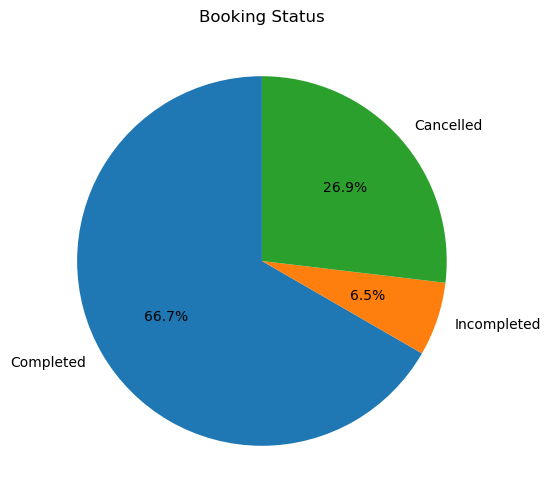

In [354]:
plt.figure(figsize=(8,6))
plt.pie(status_df['percentage'], labels=status_df['status'], autopct="%1.1f%%", startangle=90)

plt.title('Booking Status')
plt.show()

## Who cancels more: customers or drivers?

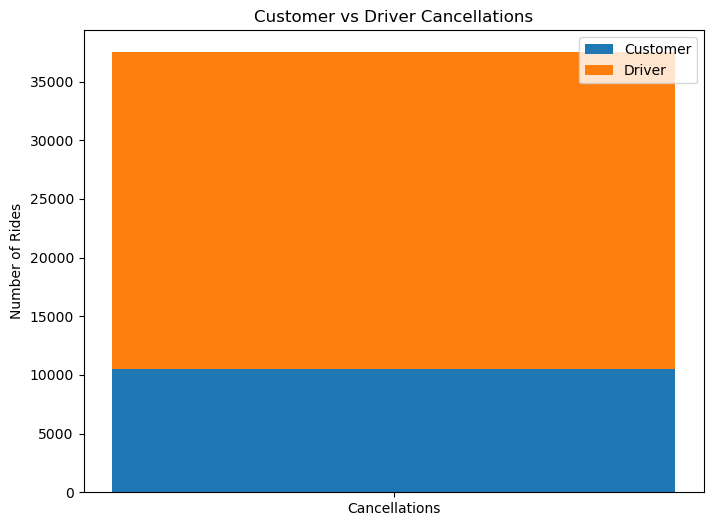

In [356]:
cancel_df = df['status'].value_counts().loc[['Cancelled by Customer', 'Cancelled by Driver']].reset_index()
cancel_df.columns = ['cancel_type', 'count']

plt.figure(figsize=(8,6))

plt.bar("Cancellations", cancel_df.loc[cancel_df['cancel_type']=="Cancelled by Customer", 'count'],
        label="Customer")
plt.bar("Cancellations", cancel_df.loc[cancel_df['cancel_type']=="Cancelled by Driver", 'count'],
        bottom=cancel_df.loc[cancel_df['cancel_type']=="Cancelled by Customer", 'count'],
        label="Driver")

plt.ylabel("Number of Rides")
plt.title("Customer vs Driver Cancellations")
plt.legend()
plt.show()

## What are the top cancellation reasons (customer vs. driver)?

In [358]:
result = df['incomplete_rides_reason'].value_counts().reset_index()

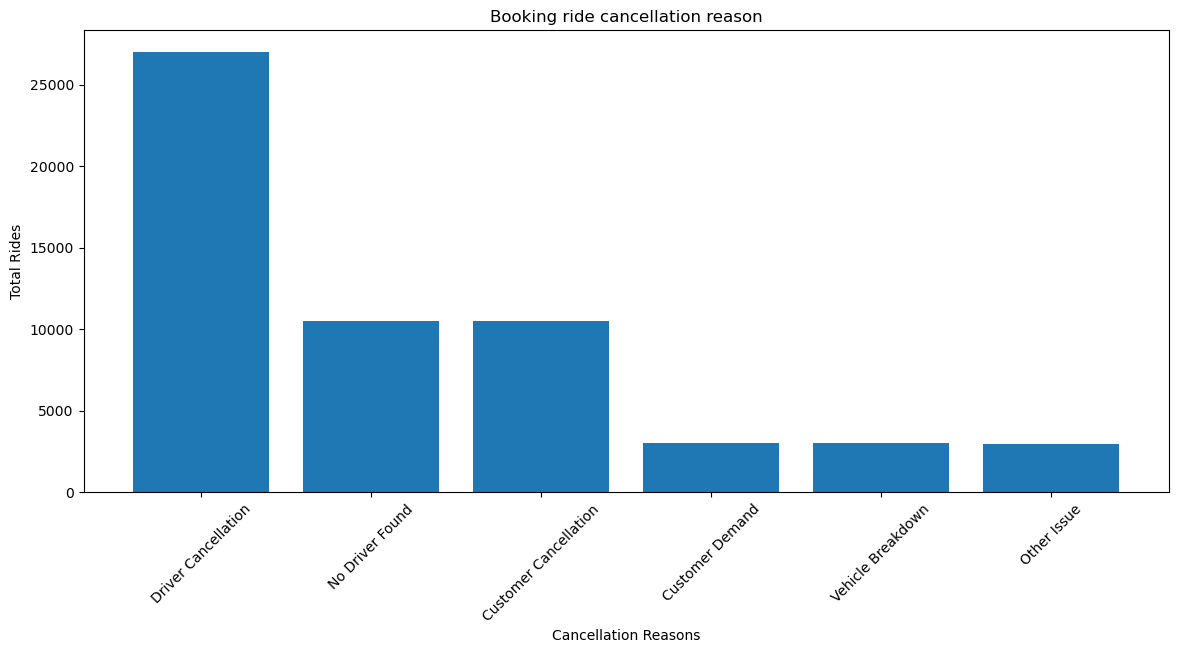

In [359]:
plt.figure(figsize=(14,6))
plt.bar(result['incomplete_rides_reason'], result['count'])

plt.xlabel('Cancellation Reasons')
plt.xticks(rotation=45)
plt.ylabel('Total Rides')
plt.title('Booking ride cancellation reason')
plt.savefig('cancellation_reason.png', dpi=300, bbox_inches='tight')
plt.show()

## At what times are cancellations highest?

In [361]:
mask = df['status'].isin(['Cancelled by Driver', 'Cancelled by Customer'])
hour = df['full_time'].dt.hour

cancel_by_hour = df[mask].groupby(hour)['booking_id'].count().reset_index(name='cancellations')

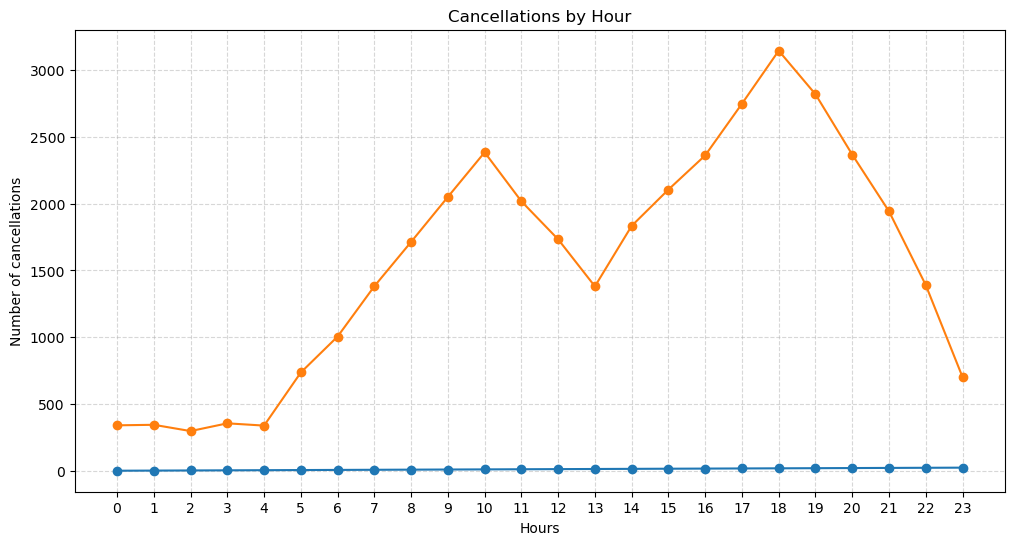

In [362]:
plt.figure(figsize=(12,6))
plt.plot(cancel_by_hour, marker='o')

plt.xlabel('Hours')
plt.ylabel('Number of cancellations')
plt.title('Cancellations by Hour')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()